# 03 — Exploratory Data Analysis

Loads `data/processed/features.csv` and explores distributions, class balance, and feature relationships.

In [ ]:
%matplotlib inline

import sys
from pathlib import Path


def _find_project_root() -> Path:
    """Locate the project root (the dir containing data/raw) regardless of
    where the Jupyter kernel was started from."""
    # 1. Walk up from the current working directory.
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "raw").is_dir():
            return candidate
    # 2. Fallback to the known absolute location of this project.
    fallback = Path("/Users/yourrem/PROJECTS/DATA_SCIENCE/Time_Series/sports_analytics")
    if (fallback / "data" / "raw").is_dir():
        return fallback
    raise FileNotFoundError(
        "Could not locate project root containing data/raw. "
        f"Searched from cwd={Path.cwd()}"
    )


PROJECT_ROOT = _find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "features.csv")
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")

## Win/Loss Tally by Current Win Streak

We first start by looking at our feature column "streak_clipped", which simply shows a teams win streak leading into a game. Below is a bar chart where each observation is a negative or positive integer value indicating a teams current win or loss streak. Negative means loss streak, and positive means win streak. Each observation additionally is broken up into to bars representing a win or a loss in the game.

Streaks beyond ±10 have very few observations and are clipped for readability.

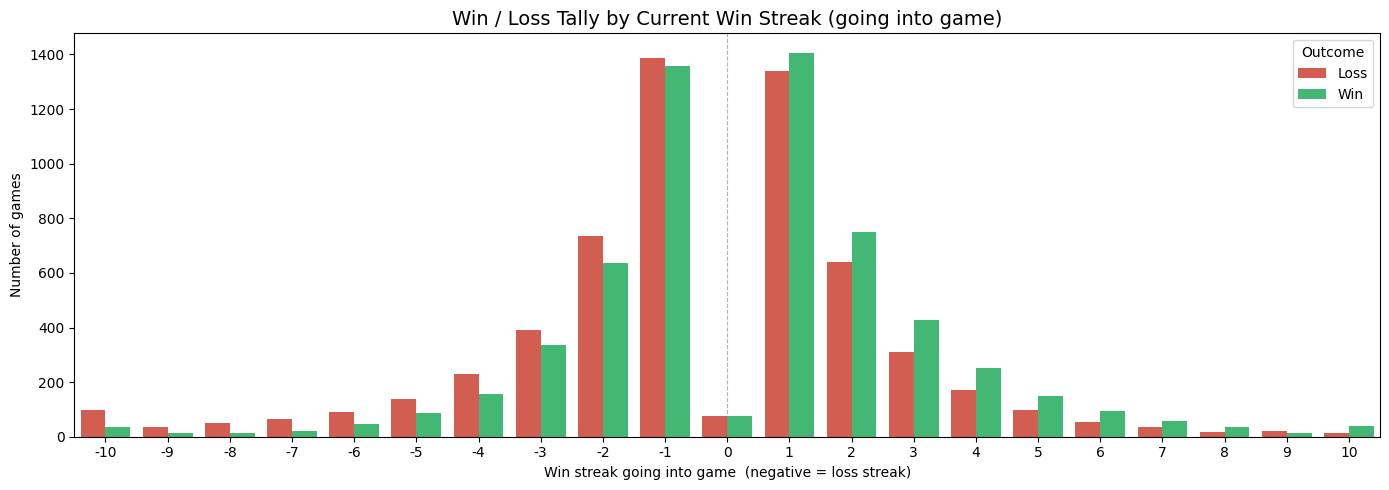

In [ ]:
CLIP = 10

plot_df = df.copy()
plot_df["streak_clipped"] = plot_df["win_streak"].clip(-CLIP, CLIP)

tally = (
    plot_df.groupby(["streak_clipped", "target"])
    .size()
    .reset_index(name="count")
)
tally["outcome"] = tally["target"].map({1: "Win", 0: "Loss"})

fig, ax = plt.subplots(figsize=(14, 5))

sns.barplot(
    data=tally,
    x="streak_clipped",
    y="count",
    hue="outcome",
    palette={"Win": "#2ecc71", "Loss": "#e74c3c"},
    ax=ax,
)

ax.set_title("Win / Loss Tally by Current Win Streak (going into game)", fontsize=14)
ax.set_xlabel("Win streak going into game  (negative = loss streak)")
ax.set_ylabel("Number of games")
ax.legend(title="Outcome")
ax.axvline(x=ax.get_xticks()[CLIP], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_win_streak_tally.png", dpi=150)
plt.show()

## Findings

First we observe the 0 observation in our graph. This is simply representing the opening games of the season, so it makes sense that these are equal, same amount of winners and losers. Next we can begin to observe the win streaks in our graph (positive integer values). We see that in general, teams that are on a win streak tend to win more often when going into a game. For example, if we look at the observation for a 2 game win streak, the difference between win and loss is more than 100 games. Inversely the same tends to be true, as when looking at loss streaks (negative integer values), we see a higher number of losses that wins. Looking at the -2 integer value we see that teams lost 100 more games than they had won. This diffrence is the most pronounced in the -10 observation, seeing more than half of the games played by teams with a current loss streak of 10 games resulting in a loss. We infer that win streak could be a helpful indicator in game outcomes, but does not paint the full picture

## Win/Loss Tally by Rest Days Before Game

Another feature we investigate further is "rest_days". In general we would expect the more a teams rests the more likely they are to win. Additionally teams that are playing back-to-back games may be more fatigued and therefore, more likley to lose. We explore this with a similar chart to our last one, with the x-axis being the amount of rest days between games, and the y-axis representing the count of the different outcomes, win or loss.

Rest values of 8+ days are the All-Star / holiday break and are grouped into a single bucket.

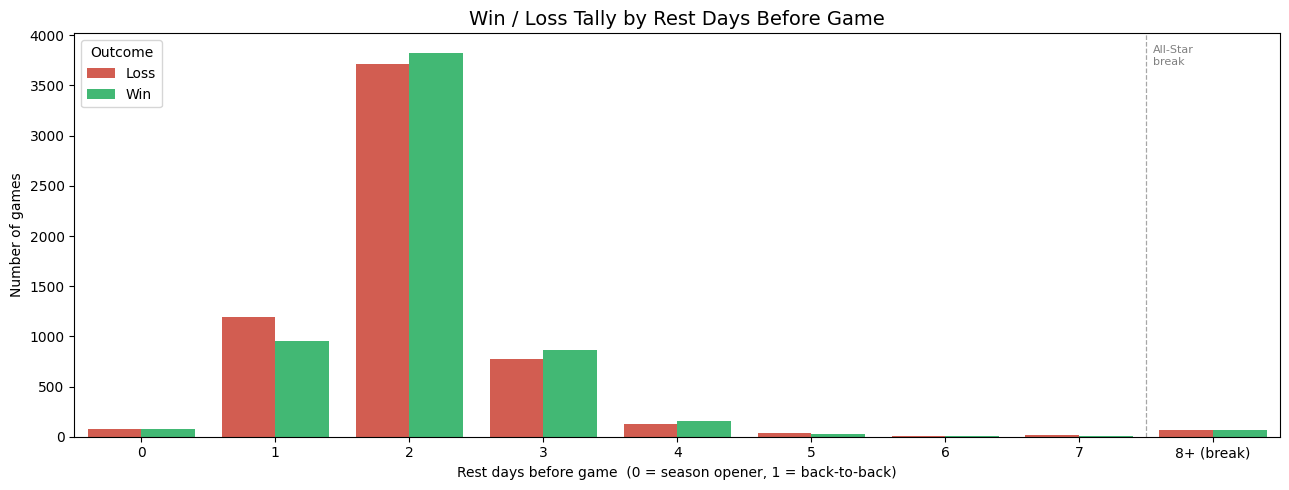

In [3]:
plot_df = df.copy()
plot_df["rest_bucket"] = plot_df["rest_days"].apply(
    lambda x: "8+ (break)" if x >= 8 else str(int(x))
)

order = [str(i) for i in range(8)] + ["8+ (break)"]

tally = (
    plot_df.groupby(["rest_bucket", "target"])
    .size()
    .reset_index(name="count")
)
tally["outcome"] = tally["target"].map({1: "Win", 0: "Loss"})

fig, ax = plt.subplots(figsize=(13, 5))

sns.barplot(
    data=tally,
    x="rest_bucket",
    y="count",
    hue="outcome",
    order=order,
    palette={"Win": "#2ecc71", "Loss": "#e74c3c"},
    ax=ax,
)

ax.set_title("Win / Loss Tally by Rest Days Before Game", fontsize=14)
ax.set_xlabel("Rest days before game  (0 = season opener, 1 = back-to-back)")
ax.set_ylabel("Number of games")
ax.legend(title="Outcome")

ax.axvline(x=7.5, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax.text(7.55, ax.get_ylim()[1] * 0.97, "All-Star\nbreak", fontsize=8,
        color="gray", va="top")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_rest_days_tally.png", dpi=150)
plt.show()

## Findings

We see that in general, differences in wins and losses between rest days are not drastically different, most of them are very similar with no clear pattern. However we do notice decent difference in the value of 1, which is encoded to represent a back-to-back game that a team has played. In general a team is slightly more likely to lose in a back-to-back matchup. For this reason we decide to keep this feature for our model